# Checkpoint Validation Metrics (Waveform)

Loads a checkpoint and computes DRR, T60, EDT, C50, and early-segment metrics on the validation split. Scatter plots compare **full predicted RIR** vs **full GT**. A second row of scatter plots keeps **x = metrics from full GT** and plots **y = metrics from a full-length hybrid**: predicted samples for the **first ~80 ms** concatenated with the **ground-truth tail**, with the tail **RMS-scaled at the splice** (last/first 160 samples of early/tail) so amplitude matches at the junction.

Also includes a **reference-RIR baseline**: for each sample, the **nearest** of the **three reference RIR waveforms** used by the model for that room (same manifest rows as ``build_ref_rir_feature_lookup``), in scaled geometry + distance — metrics and waveforms use the **full** chosen neighbor RIR only (**no** GT reverberation tail spliced into this baseline).


In [14]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
import soundfile as sf
from scipy.signal import resample
from sklearn.model_selection import train_test_split
from tqdm import tqdm

from hybrid_rir_utils import (
    JUNCTION_WIN,
    REF_RIR_COUNT,
    hybrid_pred_gt_tail_noisy,
    ref_rir_rows_by_room,
    hybrid_pred_gt_tail_scaled,
    hybrid_pred_gt_tail_wrong_t60,
)

from rir_metrics import (
    estimate_t60_t20,
    t60_percentage_error,
    compute_drr,
    estimate_edt,
    estimate_c50,
    waveform_metric_stat_box,
)

from inference_edcModelPytorchLighteningV3 import (
    load_acoustic_rooms_rows,
    build_ref_rir_feature_lookup,
    load_depth_map_for_row,
    load_model_from_checkpoint,
    predict_stft,
    infer_model_config_from_checkpoint,
    compute_room_dimensions,
)

# ------------------ Config ------------------
USE_RAW_WAVEFORMS = True
FS = 22050
WAVEFORM_LENGTH = 16000
INPUT_DIM = 13  # 12 scaled geometry + dist_m appended in model.forward
COORD_FEATURE_DIM = INPUT_DIM - 1

HEAD_MS = 80.0  # early window (ms) for hybrid / NN + GT tail splice
HYBRID_TAIL_NOISE_DB = -40.0  # additive noise on GT tail (dB re tail RMS) before junction RMS match

MAX_VAL_SAMPLES = 1000  # set None to use full validation split
VAL_SAMPLE_SEED = 42

CHECKPOINT_PATH = "Models/best_model-v18.ckpt"
SCALER_X_PATH = "Models/scaler_X_acoustic_rooms.save"
SCALER_Y_PATH = "Models/scaler_waveform_acoustic_rooms.save" if USE_RAW_WAVEFORMS else "Models/scaler_stft_acoustic_rooms.save"

DATASET_ROOT = os.environ.get("ACOUSTIC_ROOMS_ROOT", "/mnt/code/code/AcousticRooms")
IR_BASE_PATH = os.path.join(DATASET_ROOT, "single_channel_ir")
METADATA_PATH = os.path.join(DATASET_ROOT, "metadata")
DEPTH_MAP_BASE_PATH = os.path.join(DATASET_ROOT, "depth_map")


In [15]:
def load_preprocess_rir(rir_path: str, target_len: int, target_sr: int = FS):
    """Match training preprocessing + robust SR handling: resample to target_sr when needed."""
    rir, sr = sf.read(rir_path)
    sr = int(sr)
    if rir.ndim > 1:
        rir = rir[:, 0]
    rir = np.asarray(rir, dtype=np.float32).flatten()

    if sr != int(target_sr) and len(rir) > 1:
        n_out = max(1, int(round(len(rir) * float(target_sr) / float(sr))))
        rir = resample(rir, n_out).astype(np.float32)
        sr = int(target_sr)

    onset = int(np.abs(rir).argmax())
    lead_in = max(0, onset - 10)
    rir = rir[lead_in:]
    rir = rir[:target_len]
    if len(rir) < target_len:
        rir = np.pad(rir, (0, target_len - len(rir)), mode="constant")
    return rir.astype(np.float32), sr

def compute_dist_and_features(row, room_dims):
    sx, sy, sz = row["src_x"], row["src_y"], row["src_z"]
    rx, ry, rz = row["rec_x"], row["rec_y"], row["rec_z"]
    dist = float(np.sqrt((sx - rx) ** 2 + (sy - ry) ** 2 + (sz - rz) ** 2))
    dx, dy, dz = float(rx - sx), float(ry - sy), float(rz - sz)

    L, W, H = room_dims[(row["room_type"], row["room_id"])]
    geom12 = np.array([sx, sy, sz, rx, ry, rz, L, W, H, dx, dy, dz], dtype=np.float32)
    return dist, geom12

dataset_df = load_acoustic_rooms_rows(IR_BASE_PATH, METADATA_PATH)
if dataset_df.empty:
    raise RuntimeError("No samples found")

indices = np.arange(len(dataset_df))
idx_temp, idx_test = train_test_split(indices, test_size=0.2, random_state=42)
_, idx_val = train_test_split(idx_temp, test_size=0.25, random_state=42)
val_df = dataset_df.iloc[idx_val].reset_index(drop=True)

if MAX_VAL_SAMPLES is not None and len(val_df) > int(MAX_VAL_SAMPLES):
    val_df = val_df.sample(n=int(MAX_VAL_SAMPLES), random_state=VAL_SAMPLE_SEED).reset_index(drop=True)

print(f"Validation samples used: {len(val_df)} (MAX_VAL_SAMPLES={MAX_VAL_SAMPLES})")
print("Validation — rows per room_type:")
print(val_df["room_type"].value_counts().sort_index().to_string())
print(
    "Unique rooms in validation (room_type, room_id):",
    val_df.groupby(["room_type", "room_id"]).ngroups,
)

scaler_X = joblib.load(SCALER_X_PATH)
scaler_y = joblib.load(SCALER_Y_PATH)

ref_rir_lookup_scaled = build_ref_rir_feature_lookup(dataset_df, WAVEFORM_LENGTH)
room_dimensions = compute_room_dimensions(dataset_df)

model = load_model_from_checkpoint(
    CHECKPOINT_PATH,
    input_dim=INPUT_DIM,
    target_length=WAVEFORM_LENGTH if USE_RAW_WAVEFORMS else int(np.prod(scaler_y.get("shape"))),
    use_depth_map=True,
    physics_sample_rate=float(FS),
)
model.eval()

predictions = []
targets = []

for _, row in tqdm(val_df.iterrows(), total=len(val_df)):
    gt_rir, sr = load_preprocess_rir(row["rir_path"], WAVEFORM_LENGTH, target_sr=FS)
    # sr is now normalized to FS by load_preprocess_rir()

    if USE_RAW_WAVEFORMS:
        gt_target = gt_rir / (np.abs(gt_rir).max() + 1e-8)
    else:
        raise RuntimeError("Notebook currently set up for waveform mode")

    dist_m, geom12 = compute_dist_and_features(row, room_dimensions)
    x_scaled = scaler_X.transform(geom12.reshape(1, -1)).reshape(1, 1, COORD_FEATURE_DIM)

    room_key = (row["room_type"], row["room_id"])
    ref_rirs_scaled = ref_rir_lookup_scaled[room_key]

    depth_map = None
    if model.use_depth_map:
        try:
            depth_map = load_depth_map_for_row(DEPTH_MAP_BASE_PATH, row)
        except Exception:
            depth_map = np.zeros((1, 256, 512), dtype=np.float32)

    pred = predict_stft(model, scaler_y, x_scaled, ref_rirs_scaled, depth_map, dist_m=dist_m).reshape(-1)
    predictions.append(pred.astype(np.float32))
    targets.append(gt_target.astype(np.float32))

predictions = np.stack(predictions, axis=0)
targets = np.stack(targets, axis=0)
print(predictions.shape, targets.shape)

clip_n = max(1, min(int(round(FS * HEAD_MS / 1000.0)), WAVEFORM_LENGTH - 1))

def row_to_nn_feature(row):
    dist_m, geom12 = compute_dist_and_features(row, room_dimensions)
    x_scaled = scaler_X.transform(geom12.reshape(1, -1)).astype(np.float64)
    return np.concatenate([x_scaled.ravel(), np.array([float(dist_m)], dtype=np.float64)])


ref_rows_map = ref_rir_rows_by_room(dataset_df)

ref_waves_by_room = {}
for rk, sub in tqdm(ref_rows_map.items(), desc="NN baseline: cache ref-RIR waveforms per room"):
    w = np.empty((len(sub), WAVEFORM_LENGTH), dtype=np.float32)
    for k in range(len(sub)):
        gt_rir, _ = load_preprocess_rir(sub.iloc[k]["rir_path"], WAVEFORM_LENGTH, target_sr=FS)
        w[k] = (gt_rir / (np.abs(gt_rir).max() + 1e-8)).astype(np.float32)
    ref_waves_by_room[rk] = w

nn_predictions = np.empty((len(val_df), WAVEFORM_LENGTH), dtype=np.float32)
nn_ref_pick_stem = []
nn_ref_pick_rir_path = []
for i in range(len(val_df)):
    row = val_df.iloc[i]
    rk = (row["room_type"], row["room_id"])
    sub = ref_rows_map[rk]
    X_refs = np.stack([row_to_nn_feature(sub.iloc[k]) for k in range(len(sub))])
    q = row_to_nn_feature(row)
    dists = np.linalg.norm(X_refs - q, axis=1)
    best = int(np.argmin(dists))
    nn_predictions[i] = ref_waves_by_room[rk][best]
    nn_ref_pick_stem.append(str(sub.iloc[best]["stem"]))
    nn_ref_pick_rir_path.append(str(sub.iloc[best]["rir_path"]))
nn_ref_pick_stem = np.array(nn_ref_pick_stem, dtype=object)
nn_ref_pick_rir_path = np.array(nn_ref_pick_rir_path, dtype=object)

print(
    f"NN baseline: nearest of {REF_RIR_COUNT} model ref RIRs per room (scaled geom12 + dist_m); "
    "full neighbor waveform only (no GT tail splice)."
)


Validation samples used: 1000 (MAX_VAL_SAMPLES=1000)
Validation — rows per room_type:
room_type
Apartments                295
Auditorium                 40
Bathrooms                  15
Bedrooms                   62
Cafe                       33
ListeningRoom              38
LivingRoomsWithHallway    158
MeetingRoom               100
Office                     72
Restaurants               187
Unique rooms in validation (room_type, room_id): 153


100%|██████████| 1000/1000 [00:04<00:00, 214.69it/s]


(1000, 16000) (1000, 16000)


NN baseline: cache ref-RIR waveforms per room: 100%|██████████| 260/260 [00:00<00:00, 1727.72it/s]


NN baseline: nearest of 3 model ref RIRs per room (scaled geom12 + dist_m); full neighbor waveform only (no GT tail splice).


In [18]:
drr_pred = np.array([compute_drr(p, FS) for p in predictions])
drr_tgt = np.array([compute_drr(t, FS) for t in targets])
drr_errors = np.abs(drr_pred - drr_tgt)

t60_pred = np.array([estimate_t60_t20(p, FS) for p in predictions])
t60_tgt = np.array([estimate_t60_t20(t, FS) for t in targets])
t60_pct_errors = np.array([
    t60_percentage_error(predictions[i], targets[i], FS)
    for i in range(len(predictions))
])

edt_pred = np.array([estimate_edt(p, FS) for p in predictions])
edt_tgt = np.array([estimate_edt(t, FS) for t in targets])
edt_errors = np.abs(edt_pred - edt_tgt)
edt_errors = edt_errors[np.isfinite(edt_errors)]

c50_pred = np.array([estimate_c50(p, FS) for p in predictions])
c50_tgt = np.array([estimate_c50(t, FS) for t in targets])
c50_errors = np.abs(c50_pred - c50_tgt)
c50_errors = c50_errors[np.isfinite(c50_errors)]

early_cutoff = infer_model_config_from_checkpoint(CHECKPOINT_PATH)[2]
if early_cutoff is None:
    early_cutoff = 1280

pred_early = predictions[:, :early_cutoff]
tgt_early = targets[:, :early_cutoff]

early_mae = np.mean(np.abs(pred_early - tgt_early))
corrs = np.array([np.corrcoef(p, t)[0, 1] for p, t in zip(pred_early, tgt_early)])
early_corr = np.nanmean(corrs)

print(f"Mean DRR MAE: {np.mean(drr_errors):.2f} dB")
print(f"Mean T60 Error: {np.nanmean(t60_pct_errors):.1f}%")
print(
    f"Mean EDT MAE: {np.mean(edt_errors):.3f} s"
    if edt_errors.size
    else "Mean EDT MAE: n/a (no finite EDT estimates)"
)
print(
    f"Mean C50 MAE: {np.mean(c50_errors):.2f} dB"
    if c50_errors.size
    else "Mean C50 MAE: n/a (no finite C50 estimates)"
)
print(f"Early MAE: {early_mae:.4f}, Early Correlation: {early_corr:.4f}")

# --- Full-length hybrid RIR: pred for first ~HEAD_MS + noisy GT tail (clip_n from cell 2) ---


def make_hybrid_pred_gt_tail(pred: np.ndarray, tgt: np.ndarray, n_head: int) -> np.ndarray:
    """Predicted early + noisy GT tail; junction RMS match (see hybrid_pred_gt_tail_noisy)."""
    # return hybrid_pred_gt_tail_noisy(pred, tgt, n_head, noise_db=HYBRID_TAIL_NOISE_DB)
    return hybrid_pred_gt_tail_wrong_t60(pred, tgt, n_head, t60_scale=1.1)


hybrid_rir = np.stack(
    [make_hybrid_pred_gt_tail(predictions[i], targets[i], clip_n) for i in range(len(predictions))],
    axis=0,
)

drr_hybrid = np.array([compute_drr(hybrid_rir[i], FS) for i in range(len(hybrid_rir))])
t60_hybrid = np.array([estimate_t60_t20(hybrid_rir[i], FS) for i in range(len(hybrid_rir))])
edt_hybrid = np.array([estimate_edt(hybrid_rir[i], FS) for i in range(len(hybrid_rir))])
c50_hybrid = np.array([estimate_c50(hybrid_rir[i], FS) for i in range(len(hybrid_rir))])

drr_errors_hyb = np.abs(drr_hybrid - drr_tgt)
t60_pct_errors_hyb = np.array([
    t60_percentage_error(hybrid_rir[i], targets[i], FS)
    for i in range(len(hybrid_rir))
])
edt_errors_hyb = np.abs(edt_hybrid - edt_tgt)
edt_errors_hyb = edt_errors_hyb[np.isfinite(edt_errors_hyb)]
c50_errors_hyb = np.abs(c50_hybrid - c50_tgt)
c50_errors_hyb = c50_errors_hyb[np.isfinite(c50_errors_hyb)]

print(
    f"[Hybrid: pred first {HEAD_MS:.0f} ms + GT tail] Mean DRR MAE vs full GT: {np.mean(drr_errors_hyb):.2f} dB"
)
print(
    f"[Hybrid: pred first {HEAD_MS:.0f} ms + GT tail] Mean T60 Error vs full GT: {np.nanmean(t60_pct_errors_hyb):.1f}%"
)
print(
    f"[Hybrid: pred first {HEAD_MS:.0f} ms + GT tail] Mean EDT MAE vs full GT: {np.mean(edt_errors_hyb):.3f} s"
    if edt_errors_hyb.size
    else f"[Hybrid: pred first {HEAD_MS:.0f} ms + GT tail] Mean EDT MAE vs full GT: n/a (no finite EDT estimates)"
)
print(
    f"[Hybrid: pred first {HEAD_MS:.0f} ms + GT tail] Mean C50 MAE vs full GT: {np.mean(c50_errors_hyb):.2f} dB"
    if c50_errors_hyb.size
    else f"[Hybrid: pred first {HEAD_MS:.0f} ms + GT tail] Mean C50 MAE vs full GT: n/a (no finite C50 estimates)"
)

# --- Nearest-neighbor baseline (full ref neighbor RIR only — no GT tail splice), vs same GT targets ---
drr_nn = np.array([compute_drr(nn_predictions[i], FS) for i in range(len(nn_predictions))])
t60_nn = np.array([estimate_t60_t20(nn_predictions[i], FS) for i in range(len(nn_predictions))])
t60_pct_nn = np.array([
    t60_percentage_error(nn_predictions[i], targets[i], FS)
    for i in range(len(nn_predictions))
])
edt_nn = np.array([estimate_edt(nn_predictions[i], FS) for i in range(len(nn_predictions))])
c50_nn = np.array([estimate_c50(nn_predictions[i], FS) for i in range(len(nn_predictions))])

print("[NN full RIR] Mean DRR MAE:", f"{np.mean(np.abs(drr_nn - drr_tgt)):.2f} dB")
print(
    "[NN full RIR] Mean T60 Error:",
    f"{np.nanmean(t60_pct_nn):.1f}%" if np.any(np.isfinite(t60_pct_nn)) else "n/a",
)
mask_ed = np.isfinite(edt_nn) & np.isfinite(edt_tgt)
print("[NN full RIR] Mean EDT MAE:", f"{np.mean(np.abs(edt_nn[mask_ed] - edt_tgt[mask_ed])):.3f} s" if np.any(mask_ed) else "n/a")
mask_c = np.isfinite(c50_nn) & np.isfinite(c50_tgt)
print("[NN full RIR] Mean C50 MAE:", f"{np.mean(np.abs(c50_nn[mask_c] - c50_tgt[mask_c])):.2f} dB" if np.any(mask_c) else "n/a")


Mean DRR MAE: 3.69 dB
Mean T60 Error: 55.1%
Mean EDT MAE: 0.179 s
Mean C50 MAE: 2.50 dB
Early MAE: 0.0642, Early Correlation: 0.1063
[Hybrid: pred first 80 ms + GT tail] Mean DRR MAE vs full GT: 3.09 dB
[Hybrid: pred first 80 ms + GT tail] Mean T60 Error vs full GT: 19.7%
[Hybrid: pred first 80 ms + GT tail] Mean EDT MAE vs full GT: 0.097 s
[Hybrid: pred first 80 ms + GT tail] Mean C50 MAE vs full GT: 1.61 dB
[NN full RIR] Mean DRR MAE: 2.49 dB
[NN full RIR] Mean T60 Error: 13.4%
[NN full RIR] Mean EDT MAE: 0.087 s
[NN full RIR] Mean C50 MAE: 1.51 dB


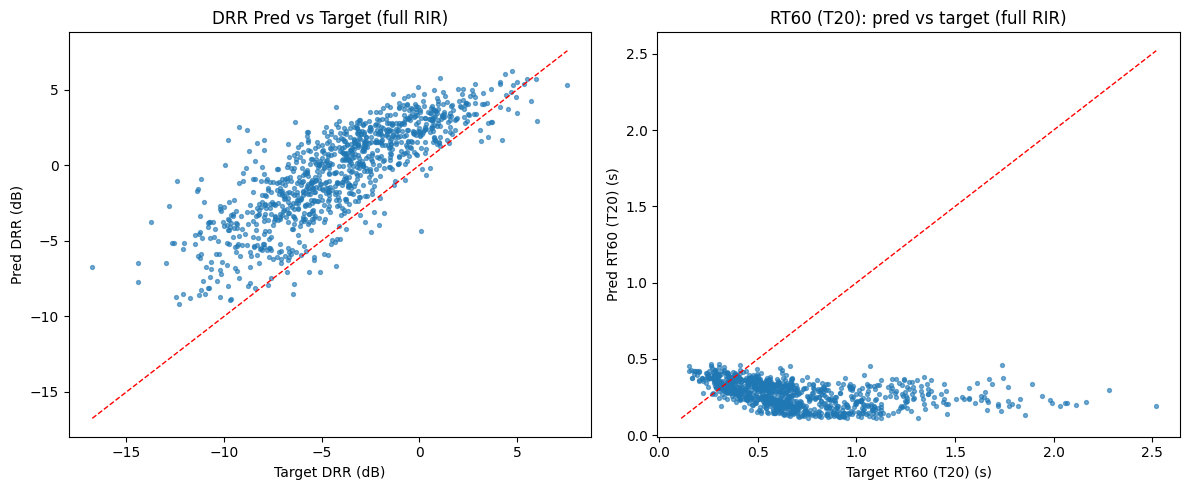

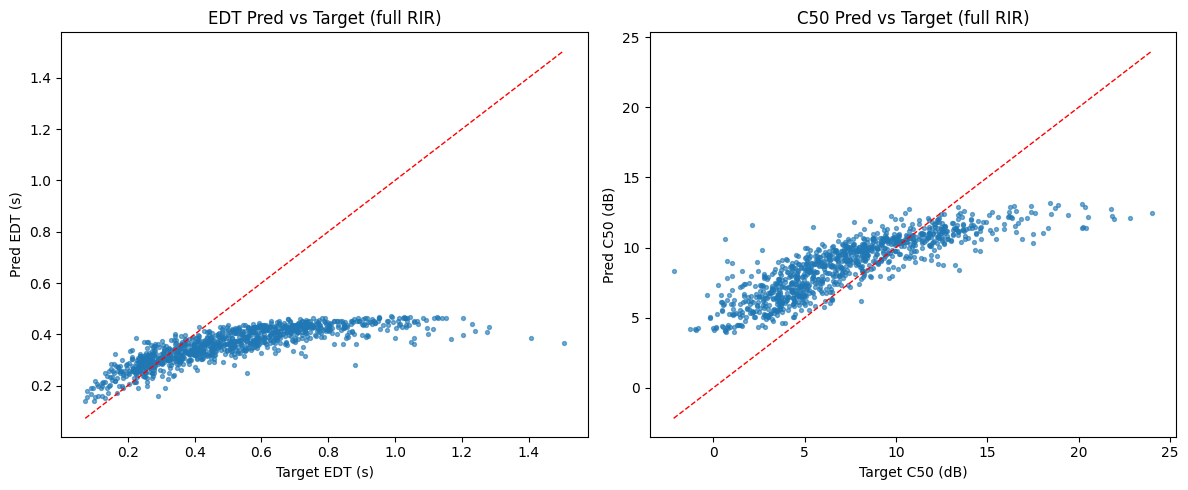

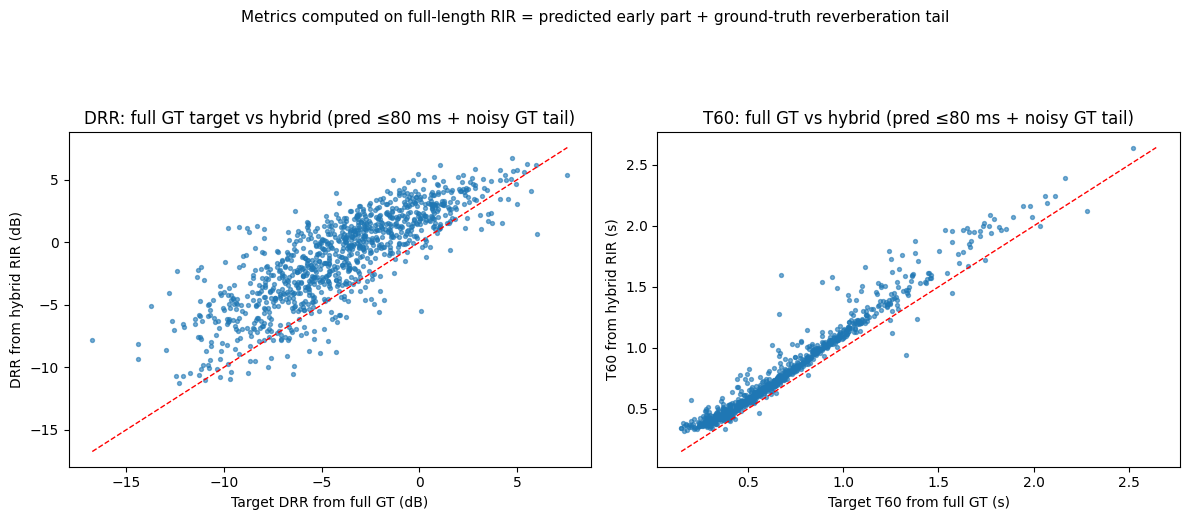

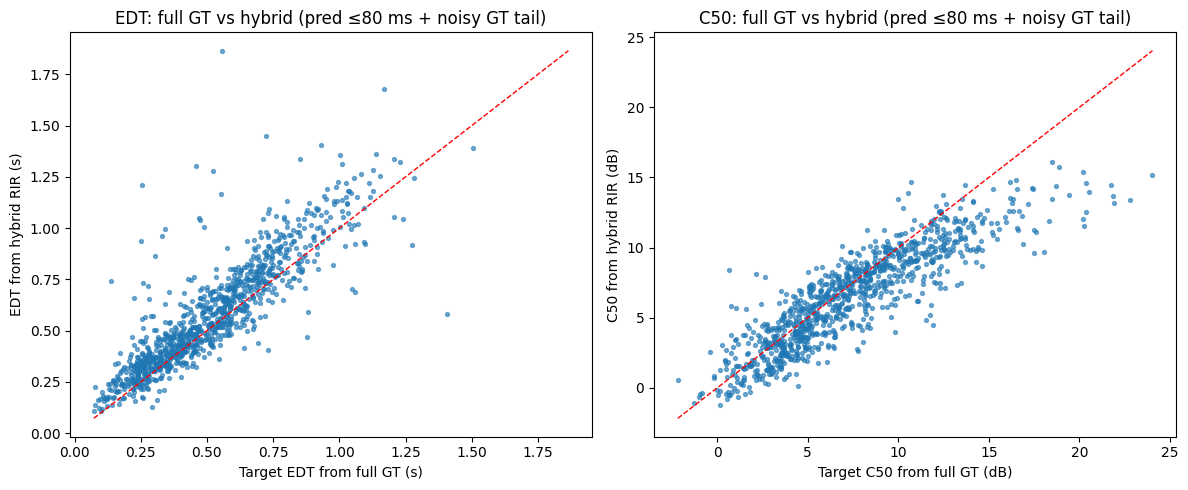

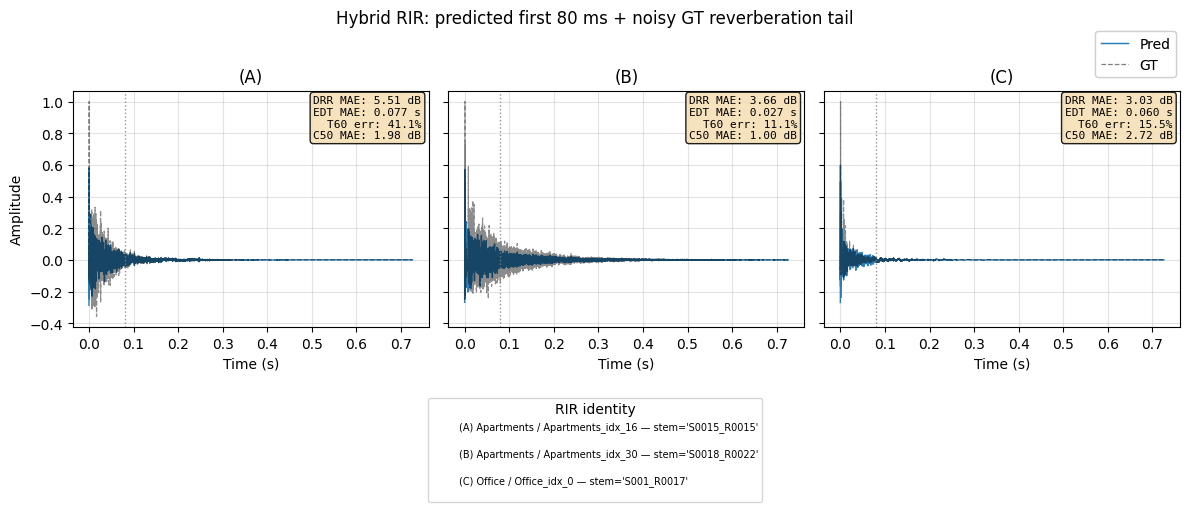

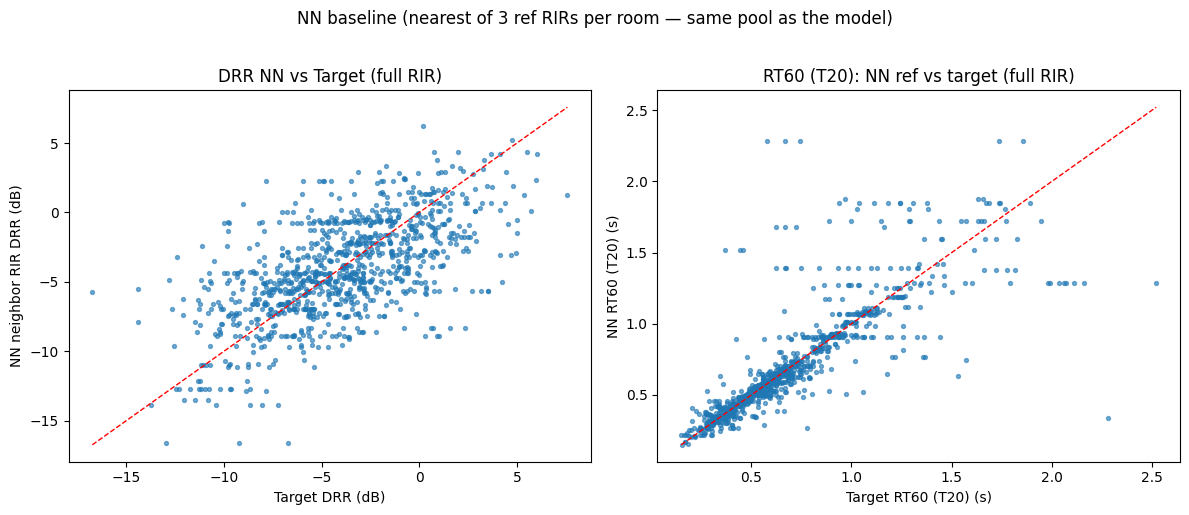

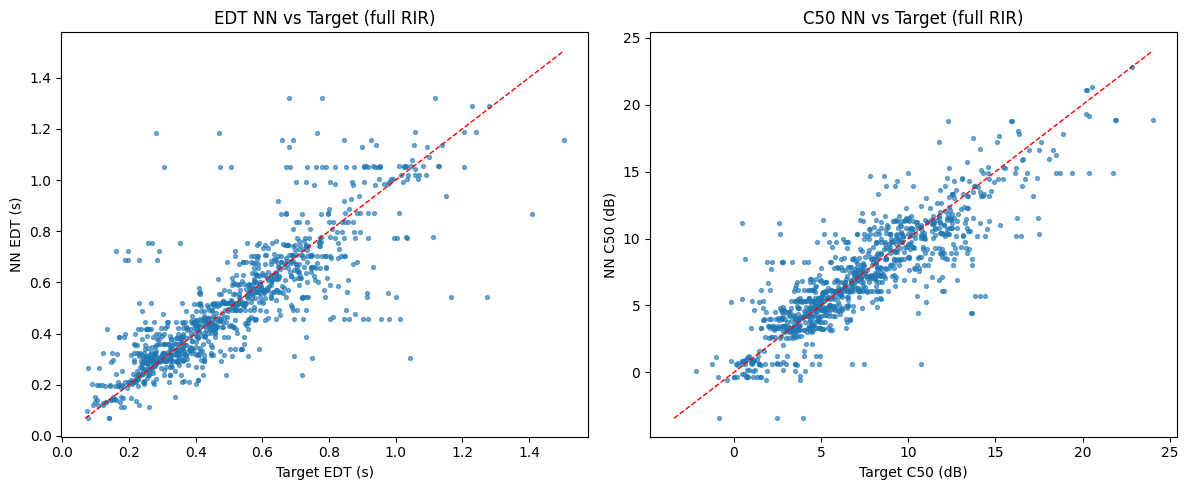

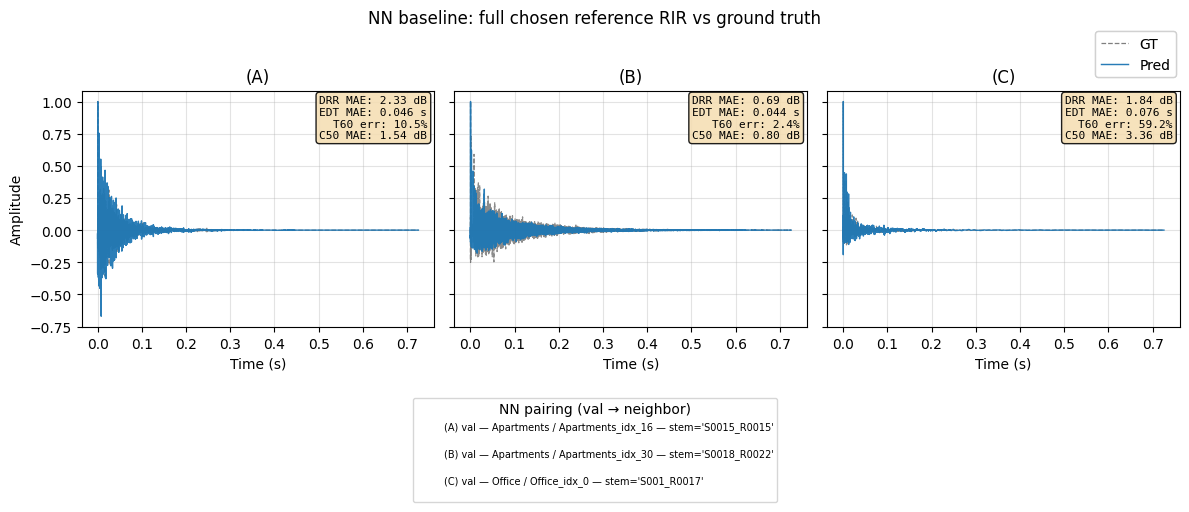

In [24]:
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

axs[0].scatter(drr_tgt, drr_pred, s=8, alpha=0.6)
mn, mx = min(drr_tgt.min(), drr_pred.min()), max(drr_tgt.max(), drr_pred.max())
axs[0].plot([mn, mx], [mn, mx], "r--", linewidth=1)
axs[0].set_title("DRR Pred vs Target (full RIR)")
axs[0].set_xlabel("Target DRR (dB)")
axs[0].set_ylabel("Pred DRR (dB)")

mask = np.isfinite(t60_pred) & np.isfinite(t60_tgt)
axs[1].scatter(t60_tgt[mask], t60_pred[mask], s=8, alpha=0.6)
if np.any(mask):
    mn2, mx2 = min(t60_tgt[mask].min(), t60_pred[mask].min()), max(t60_tgt[mask].max(), t60_pred[mask].max())
    axs[1].plot([mn2, mx2], [mn2, mx2], "r--", linewidth=1)
axs[1].set_title("RT60 (T20): pred vs target (full RIR)")
axs[1].set_xlabel("Target RT60 (T20) (s)")
axs[1].set_ylabel("Pred RT60 (T20) (s)")

plt.tight_layout()
plt.show()

fig2, ax2 = plt.subplots(1, 2, figsize=(12, 5))

mask_e = np.isfinite(edt_pred) & np.isfinite(edt_tgt)
ax2[0].scatter(edt_tgt[mask_e], edt_pred[mask_e], s=8, alpha=0.6)
if np.any(mask_e):
    me, Me = min(edt_tgt[mask_e].min(), edt_pred[mask_e].min()), max(edt_tgt[mask_e].max(), edt_pred[mask_e].max())
    ax2[0].plot([me, Me], [me, Me], "r--", linewidth=1)
ax2[0].set_title("EDT Pred vs Target (full RIR)")
ax2[0].set_xlabel("Target EDT (s)")
ax2[0].set_ylabel("Pred EDT (s)")

mask_c = np.isfinite(c50_pred) & np.isfinite(c50_tgt)
ax2[1].scatter(c50_tgt[mask_c], c50_pred[mask_c], s=8, alpha=0.6)
if np.any(mask_c):
    mc, Mc = min(c50_tgt[mask_c].min(), c50_pred[mask_c].min()), max(c50_tgt[mask_c].max(), c50_pred[mask_c].max())
    ax2[1].plot([mc, Mc], [mc, Mc], "r--", linewidth=1)
ax2[1].set_title("C50 Pred vs Target (full RIR)")
ax2[1].set_xlabel("Target C50 (dB)")
ax2[1].set_ylabel("Pred C50 (dB)")

plt.tight_layout()
plt.show()

# --- Scatter: full-GT target metrics (x) vs metrics on full-length hybrid RIR (pred early + GT tail) ---
fig_c, axc = plt.subplots(1, 2, figsize=(12, 5))

axc[0].scatter(drr_tgt, drr_hybrid, s=8, alpha=0.6)
mn, mx = min(drr_tgt.min(), drr_hybrid.min()), max(drr_tgt.max(), drr_hybrid.max())
axc[0].plot([mn, mx], [mn, mx], "r--", linewidth=1)
axc[0].set_title(f"DRR: full GT target vs hybrid (pred ≤{HEAD_MS:.0f} ms + noisy GT tail)")
axc[0].set_xlabel("Target DRR from full GT (dB)")
axc[0].set_ylabel("DRR from hybrid RIR (dB)")

mask = np.isfinite(t60_hybrid) & np.isfinite(t60_tgt)
axc[1].scatter(t60_tgt[mask], t60_hybrid[mask], s=8, alpha=0.6)
if np.any(mask):
    mn2, mx2 = min(t60_tgt[mask].min(), t60_hybrid[mask].min()), max(t60_tgt[mask].max(), t60_hybrid[mask].max())
    axc[1].plot([mn2, mx2], [mn2, mx2], "r--", linewidth=1)
axc[1].set_title(f"T60: full GT vs hybrid (pred ≤{HEAD_MS:.0f} ms + noisy GT tail)")
axc[1].set_xlabel("Target T60 from full GT (s)")
axc[1].set_ylabel("T60 from hybrid RIR (s)")

fig_c.suptitle(
    "Metrics computed on full-length RIR = predicted early part + ground-truth reverberation tail",
    y=1.03,
    fontsize=11,
)
fig_c.tight_layout(rect=[0, 0, 1, 0.92])
plt.show()

fig_c2, axc2 = plt.subplots(1, 2, figsize=(12, 5))

mask_e = np.isfinite(edt_hybrid) & np.isfinite(edt_tgt)
axc2[0].scatter(edt_tgt[mask_e], edt_hybrid[mask_e], s=8, alpha=0.6)
if np.any(mask_e):
    me, Me = min(edt_tgt[mask_e].min(), edt_hybrid[mask_e].min()), max(edt_tgt[mask_e].max(), edt_hybrid[mask_e].max())
    axc2[0].plot([me, Me], [me, Me], "r--", linewidth=1)
axc2[0].set_title(f"EDT: full GT vs hybrid (pred ≤{HEAD_MS:.0f} ms + noisy GT tail)")
axc2[0].set_xlabel("Target EDT from full GT (s)")
axc2[0].set_ylabel("EDT from hybrid RIR (s)")

mask_c = np.isfinite(c50_hybrid) & np.isfinite(c50_tgt)
axc2[1].scatter(c50_tgt[mask_c], c50_hybrid[mask_c], s=8, alpha=0.6)
if np.any(mask_c):
    mc, Mc = min(c50_tgt[mask_c].min(), c50_hybrid[mask_c].min()), max(c50_tgt[mask_c].max(), c50_hybrid[mask_c].max())
    axc2[1].plot([mc, Mc], [mc, Mc], "r--", linewidth=1)
axc2[1].set_title(f"C50: full GT vs hybrid (pred ≤{HEAD_MS:.0f} ms + noisy GT tail)")
axc2[1].set_xlabel("Target C50 from full GT (dB)")
axc2[1].set_ylabel("C50 from hybrid RIR (dB)")

plt.tight_layout()
plt.show()

# Hybrid waveform overlay (same style as train_single_room §9 Graph 4: pred early + GT tail)
n_show = min(3, len(predictions))
_t_sec = clip_n / float(FS)
fig_e, axs_e = plt.subplots(1, n_show, figsize=(4 * n_show, 3.8), sharey=True)
if n_show == 1:
    axs_e = [axs_e]
for i in range(n_show):
    hybrid = np.asarray(hybrid_rir[i], dtype=np.float64).flatten()
    actual_w = np.asarray(targets[i], dtype=np.float64).flatten()
    Lc = min(len(hybrid), len(actual_w))
    hybrid = hybrid[:Lc]
    actual_w = actual_w[:Lc]
    t_h = np.arange(Lc) / float(FS)
    # Match train_single_room graph 4: colored trace then dashed GT
    axs_e[i].plot(t_h, hybrid, linewidth=1.0, alpha=0.95, color="C0", label="Pred")
    axs_e[i].plot(t_h, actual_w, "k--", linewidth=0.9, alpha=0.45, label="GT")
    axs_e[i].axvline(_t_sec, color="gray", linestyle=":", linewidth=1.0, alpha=0.85)
    axs_e[i].set_title(f"({chr(65 + i)})")
    axs_e[i].set_xlabel("Time (s)")
    axs_e[i].grid(True, alpha=0.35)
    waveform_metric_stat_box(axs_e[i], hybrid.astype(np.float32), actual_w.astype(np.float32), FS)

axs_e[0].set_ylabel("Amplitude")
handles_e, labels_e = axs_e[0].get_legend_handles_labels()
leg_wave_e = fig_e.legend(
    handles_e,
    labels_e,
    loc="upper right",
    bbox_to_anchor=(0.99, 0.97),
    bbox_transform=fig_e.transFigure,
)
fig_e.add_artist(leg_wave_e)

legend_lines = []
for i in range(n_show):
    row = val_df.iloc[i]
    legend_lines.append(
        f"({chr(65 + i)}) {row['room_type']} / {row['room_id']} — stem={row['stem']!r}\n"
        # f"    {row['rir_path']}"
    )
from matplotlib.lines import Line2D

dummy = [Line2D([], [], linestyle="none", marker="")] * len(legend_lines)
fig_e.legend(
    dummy,
    legend_lines,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.3),
    bbox_transform=fig_e.transFigure,
    fontsize=7,
    frameon=True,
    title="RIR identity",
)
fig_e.suptitle(
    f"Hybrid RIR: predicted first {clip_n / FS * 1000:.0f} ms + noisy GT reverberation tail",
    y=1.01,
)
plt.tight_layout(rect=[0, 0.02, 1, 0.98])
plt.show()

# ========== Nearest-neighbor baseline (same figure types as above) ==========
fig_nn, ax_nn = plt.subplots(1, 2, figsize=(12, 5))
ax_nn[0].scatter(drr_tgt, drr_nn, s=8, alpha=0.6)
mn, mx = min(drr_tgt.min(), drr_nn.min()), max(drr_tgt.max(), drr_nn.max())
ax_nn[0].plot([mn, mx], [mn, mx], "r--", linewidth=1)
ax_nn[0].set_title("DRR NN vs Target (full RIR)")
ax_nn[0].set_xlabel("Target DRR (dB)")
ax_nn[0].set_ylabel("NN neighbor RIR DRR (dB)")

mask = np.isfinite(t60_nn) & np.isfinite(t60_tgt)
ax_nn[1].scatter(t60_tgt[mask], t60_nn[mask], s=8, alpha=0.6)
if np.any(mask):
    mn2, mx2 = min(t60_tgt[mask].min(), t60_nn[mask].min()), max(t60_tgt[mask].max(), t60_nn[mask].max())
    ax_nn[1].plot([mn2, mx2], [mn2, mx2], "r--", linewidth=1)
ax_nn[1].set_title("RT60 (T20): NN ref vs target (full RIR)")
ax_nn[1].set_xlabel("Target RT60 (T20) (s)")
ax_nn[1].set_ylabel("NN RT60 (T20) (s)")
fig_nn.suptitle("NN baseline (nearest of 3 ref RIRs per room — same pool as the model)", y=1.02)
plt.tight_layout()
plt.show()

fig_nn2, ax_nn2 = plt.subplots(1, 2, figsize=(12, 5))
mask_e = np.isfinite(edt_nn) & np.isfinite(edt_tgt)
ax_nn2[0].scatter(edt_tgt[mask_e], edt_nn[mask_e], s=8, alpha=0.6)
if np.any(mask_e):
    me, Me = min(edt_tgt[mask_e].min(), edt_nn[mask_e].min()), max(edt_tgt[mask_e].max(), edt_nn[mask_e].max())
    ax_nn2[0].plot([me, Me], [me, Me], "r--", linewidth=1)
ax_nn2[0].set_title("EDT NN vs Target (full RIR)")
ax_nn2[0].set_xlabel("Target EDT (s)")
ax_nn2[0].set_ylabel("NN EDT (s)")

mask_c = np.isfinite(c50_nn) & np.isfinite(c50_tgt)
ax_nn2[1].scatter(c50_tgt[mask_c], c50_nn[mask_c], s=8, alpha=0.6)
if np.any(mask_c):
    mc, Mc = min(c50_tgt[mask_c].min(), c50_nn[mask_c].min()), max(c50_tgt[mask_c].max(), c50_nn[mask_c].max())
    ax_nn2[1].plot([mc, Mc], [mc, Mc], "r--", linewidth=1)
ax_nn2[1].set_title("C50 NN vs Target (full RIR)")
ax_nn2[1].set_xlabel("Target C50 (dB)")
ax_nn2[1].set_ylabel("NN C50 (dB)")
plt.tight_layout()
plt.show()

fig_nn_e, axs_nn_e = plt.subplots(1, n_show, figsize=(4 * n_show, 3.8), sharey=True)
if n_show == 1:
    axs_nn_e = [axs_nn_e]
for i in range(n_show):
    pred_nn = np.asarray(nn_predictions[i], dtype=np.float64).flatten()
    actual_w = np.asarray(targets[i], dtype=np.float64).flatten()
    Lc = min(len(pred_nn), len(actual_w))
    pred_nn = pred_nn[:Lc]
    actual_w = actual_w[:Lc]
    t_h = np.arange(Lc) / float(FS)
    # Match train_single_room graph 3: dashed GT then colored Pred
    axs_nn_e[i].plot(t_h, actual_w, "k--", linewidth=0.9, alpha=0.45, label="GT")
    axs_nn_e[i].plot(t_h, pred_nn, linewidth=1.0, alpha=0.95, color="C0", label="Pred")
    axs_nn_e[i].set_title(f"({chr(65 + i)})")
    axs_nn_e[i].set_xlabel("Time (s)")
    axs_nn_e[i].grid(True, alpha=0.35)
    waveform_metric_stat_box(axs_nn_e[i], pred_nn.astype(np.float32), actual_w.astype(np.float32), FS)

axs_nn_e[0].set_ylabel("Amplitude")
handles_nn, labels_nn = axs_nn_e[0].get_legend_handles_labels()
leg_wave_nn = fig_nn_e.legend(
    handles_nn,
    labels_nn,
    loc="upper right",
    bbox_to_anchor=(0.99, 0.97),
    bbox_transform=fig_nn_e.transFigure,
)
fig_nn_e.add_artist(leg_wave_nn)

legend_lines_nn = []
for i in range(n_show):
    row = val_df.iloc[i]
    legend_lines_nn.append(
        f"({chr(65 + i)}) val — {row['room_type']} / {row['room_id']} — stem={row['stem']!r}\n"
    )
dummy_nn = [Line2D([], [], linestyle="none", marker="")] * len(legend_lines_nn)
fig_nn_e.legend(
    dummy_nn,
    legend_lines_nn,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.3),
    bbox_transform=fig_nn_e.transFigure,
    fontsize=7,
    frameon=True,
    title="NN pairing (val → neighbor)",
)
fig_nn_e.suptitle(
    "NN baseline: full chosen reference RIR vs ground truth",
    y=1.01,
)
plt.tight_layout(rect=[0, 0.02, 1, 0.98])
plt.show()

